First 5 rows:
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80    

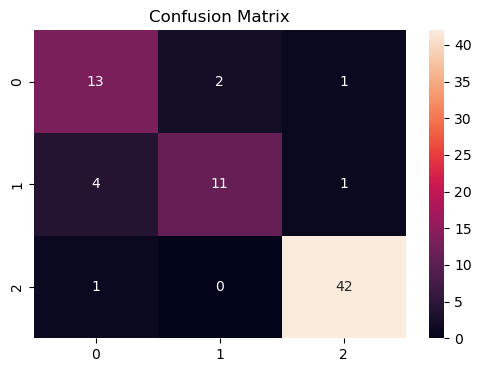


Predicted Sleep Disorder: [2]


In [2]:
 # Sleep Disorder Diagnosis using Machine Learning

# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt


# Load Dataset
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

print("First 5 rows:")
print(df.head())


# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


# Encode Categorical Columns
label_encoder = LabelEncoder()

for column in df.select_dtypes(include='object'):
    df[column] = label_encoder.fit_transform(df[column])


# Features and Target
X = df.drop("Sleep Disorder", axis=1)
y = df["Sleep Disorder"]


# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# Model Training
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


# Predictions
y_pred = model.predict(X_test)


# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)


# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


# --------- Predict New Data ---------

sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

print("\nPredicted Sleep Disorder:", prediction)